# Phase 1: Setup & Data Validation

## 1. Import and load data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats as scipy_stats


In [2]:
data = pd.read_csv(Path("..") / "data" / "processed" / "merged" / "master_occupations.csv")

## 2. Understand data structure and format

In [3]:
print("== Shape ==")
print(f"Rows: {data.shape[0]:,}")
print(f"Columns: {data.shape[1]}")

== Shape ==
Rows: 655
Columns: 122


In [4]:
print("== First 5 rows ==")
data.head()

== First 5 rows ==


,OCC_CODE,arm_hand_steadiness,auditory_attention,category_flexibility,control_precision,deductive_reasoning,depth_perception,dynamic_flexibility,dynamic_strength,explosive_strength,...,TOT_EMP_2024,real_median_wage_2019,real_median_wage_2022,real_median_wage_2024,emp_change_pct_19_24,emp_change_pct_19_22,emp_change_pct_22_24,wage_change_pct_19_24,wage_change_pct_19_22,wage_change_pct_22_24
0,11-1011,1.19,2.06,3.31,1.625,4.00,1.875,1.0,1.125,1.00,...,211850.0,214526.98,204871.12,206420.0,2.894750,-3.229880,6.329050,-3.779003,-4.501000,0.756027
1,11-1021,1.62,2.12,3.38,1.120,3.88,1.880,1.0,1.120,1.38,...,3584420.0,117207.14,106046.10,102950.0,49.333411,40.678587,6.152197,-12.164054,-9.522492,-2.919579
2,11-2011,1.38,1.75,3.38,1.120,3.88,1.750,1.0,1.000,1.00,...,21100.0,145968.13,138184.23,126960.0,-15.936255,-12.310757,-4.134484,-13.022110,-5.332602,-8.122656
3,11-2021,1.12,1.88,3.25,1.000,3.88,1.750,1.0,1.250,1.00,...,384980.0,159156.55,151383.24,161030.0,46.002731,24.609375,17.168336,1.177111,-4.884065,6.372410
4,11-2022,1.12,1.88,3.25,1.380,3.88,1.500,1.0,1.000,1.00,...,603710.0,147282.32,141178.60,138060.0,49.952807,33.231495,12.550570,-6.261661,-4.144231,-2.208975


# Phase 2: Cross-sectional Exposure Patterns

## 1. AIOE score distribution across occupations

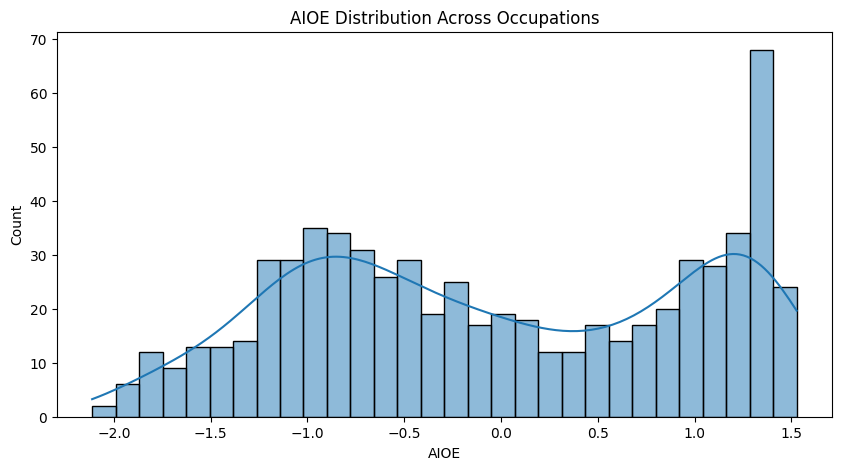

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x="AIOE", bins=30, kde=True)
plt.title("AIOE Distribution Across Occupations")
plt.xlabel("AIOE")
plt.ylabel("Count")
plt.show()

## 2. AIOE by occupation group (most/least exposed)

In [6]:
group_stats = (
    data.groupby("occ_major_group", dropna=False)["AIOE"]
      .agg(["mean", "median", "count"])
      .sort_values("mean", ascending=False)
)

### 2.1 Most exposed groups

In [7]:
display(group_stats.head(10))

,mean,median,count
occ_major_group,,,
Computer & Math,1.442884,1.436170,4
Legal,1.380938,1.374714,7
Business & Financial,1.190365,1.345268,25
Education,1.003994,1.269028,52
Management,1.000403,1.108003,28
"Life, Physical & Social Science",0.913593,1.032757,37
Architecture & Engineering,0.826864,0.940964,33
Community & Social Service,0.823996,0.855068,12
Office & Admin Support,0.672583,1.013863,50


### 2.2 Least exposed groups

In [8]:
display(group_stats.tail(10))

,mean,median,count
occ_major_group,,,
Protective Service,-0.380815,-0.508587,20
Healthcare Support,-0.384482,-0.526876,13
Personal Care,-0.432397,-0.418420,24
Transportation,-0.755664,-0.832091,37
Food Preparation,-0.802584,-0.720102,14
Production,-0.830191,-0.906209,93
Installation & Repair,-0.866395,-0.890251,50
Farming & Fishing,-0.992640,-1.064205,11
Building & Grounds,-1.152352,-1.160497,8


### 2.3 AIOE by Occupation Major Group

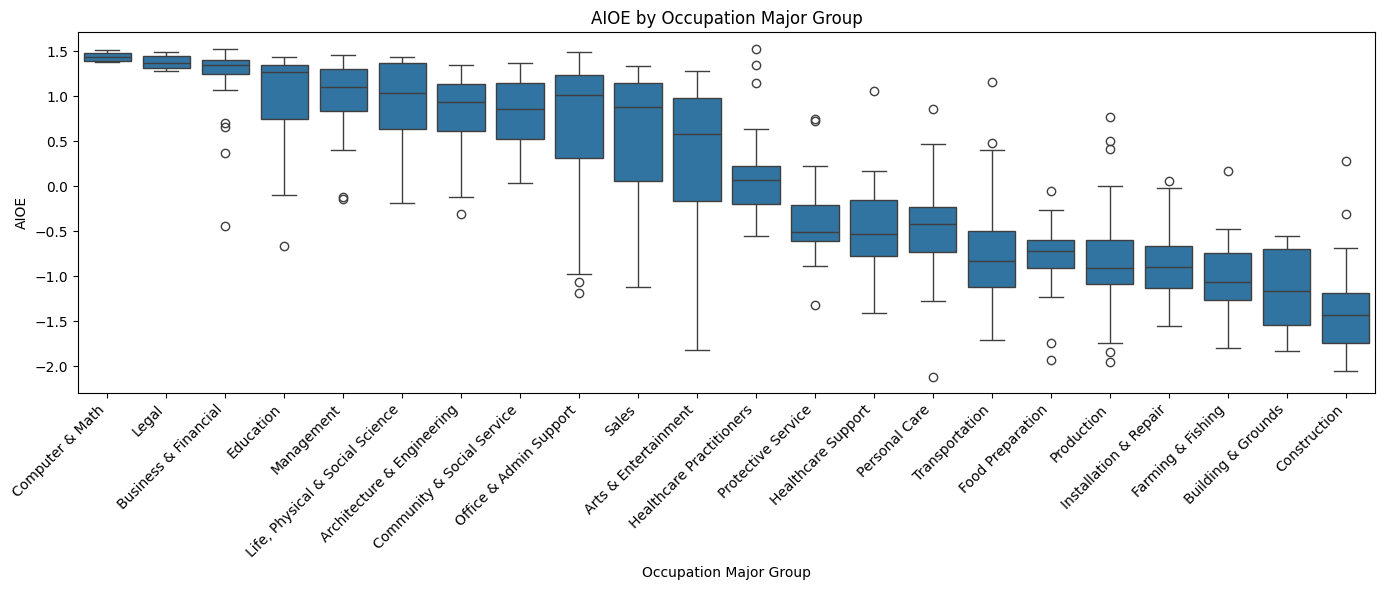

In [9]:
order = group_stats.index
plt.figure(figsize=(14, 6))
sns.boxplot(data=data, x="occ_major_group", y="AIOE", order=order)
plt.title("AIOE by Occupation Major Group")
plt.xlabel("Occupation Major Group")
plt.ylabel("AIOE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. AIOE vs median wage 2024 scatter

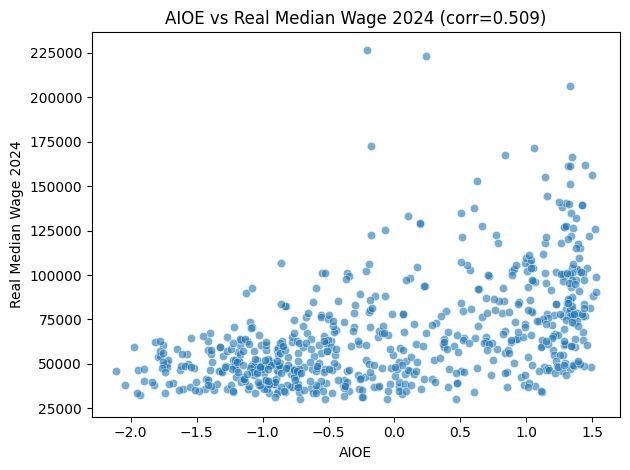

In [10]:
plot_df = data[["AIOE", "real_median_wage_2024"]].dropna()
corr_wage = plot_df["AIOE"].corr(plot_df["real_median_wage_2024"])

sns.scatterplot(data=plot_df, x="AIOE", y="real_median_wage_2024", alpha=0.6)
plt.title(f"AIOE vs Real Median Wage 2024 (corr={corr_wage:.3f})")
plt.xlabel("AIOE")
plt.ylabel("Real Median Wage 2024")
plt.tight_layout()
plt.show()

## 4. AIOE vs employment change (2019 to 2024) scatter

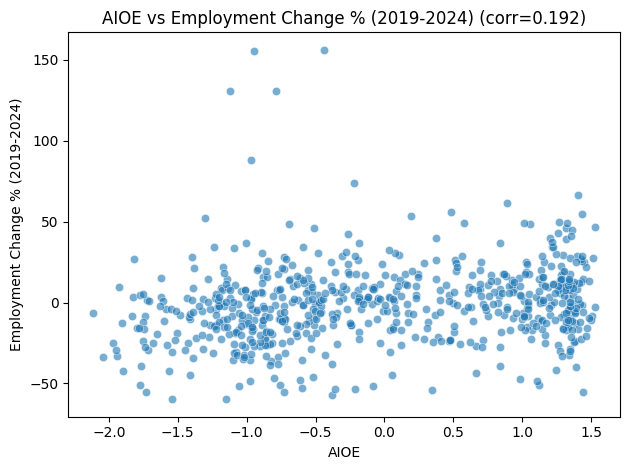

In [11]:
plot_df = data[["AIOE", "emp_change_pct_19_24"]].dropna()
corr_emp = plot_df["AIOE"].corr(plot_df["emp_change_pct_19_24"])

sns.scatterplot(data=plot_df, x="AIOE", y="emp_change_pct_19_24", alpha=0.6)
plt.title(f"AIOE vs Employment Change % (2019-2024) (corr={corr_emp:.3f})")
plt.xlabel("AIOE")
plt.ylabel("Employment Change % (2019-2024)")
plt.tight_layout()
plt.show()

# Phase 3: Trend Analysis by AIOE Quartile

In [12]:
df_q = data.copy()
df_q["AIOE_quartile"] = pd.qcut(df_q["AIOE"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])
df_q[["AIOE", "AIOE_quartile"]].head()

,AIOE,AIOE_quartile
0,1.334246,Q4
1,0.574877,Q3
2,1.294387,Q4
3,1.315032,Q4
4,1.266280,Q4


## 1. Employment trends by AIOE quartile (2019, 2022, 2024)

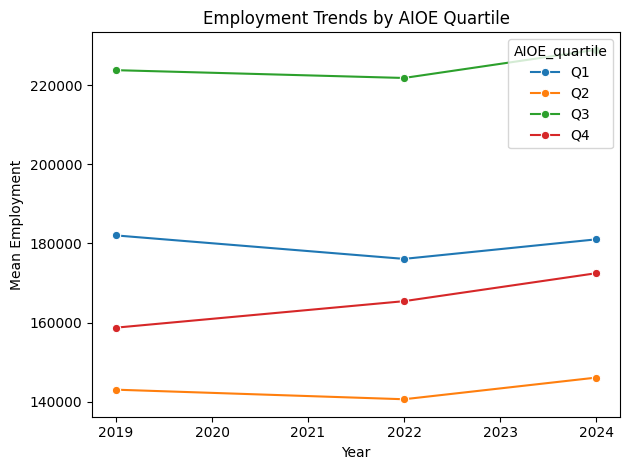

In [13]:
emp_summary = (
    df_q.groupby("AIOE_quartile")[["TOT_EMP_2019", "TOT_EMP_2022", "TOT_EMP_2024"]]
        .mean()
        .reset_index()
)

emp_long = emp_summary.melt(id_vars="AIOE_quartile", var_name="Year", value_name="Mean_Employment")
emp_long["Year"] = emp_long["Year"].str.extract(r"(\d{4})").astype(int)

sns.lineplot(data=emp_long, x="Year", y="Mean_Employment", hue="AIOE_quartile", marker="o")
plt.title("Employment Trends by AIOE Quartile")
plt.xlabel("Year")
plt.ylabel("Mean Employment")
plt.tight_layout()
plt.show()

## 2. Wage trends by AIOE quartile (2019, 2022, 2024)

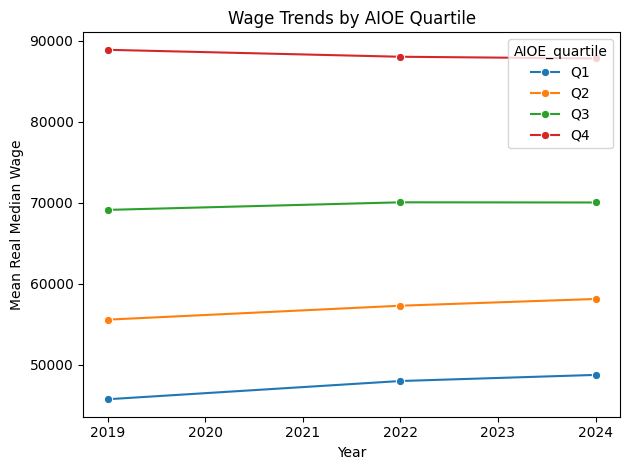

In [14]:
wage_summary = (
    df_q.groupby("AIOE_quartile")[["real_median_wage_2019", "real_median_wage_2022", "real_median_wage_2024"]]
        .mean()
        .reset_index()
)

wage_long = wage_summary.melt(id_vars="AIOE_quartile", var_name="Year", value_name="Mean_Real_Wage")
wage_long["Year"] = wage_long["Year"].str.extract(r"(\d{4})").astype(int)

sns.lineplot(data=wage_long, x="Year", y="Mean_Real_Wage", hue="AIOE_quartile", marker="o")
plt.title("Wage Trends by AIOE Quartile")
plt.xlabel("Year")
plt.ylabel("Mean Real Median Wage")
plt.tight_layout()
plt.show()

# Phase 4: Ranked Occupation Tables

In [15]:
cols = ["OCC_CODE", "OCC_TITLE", "occ_major_group", "AIOE",
        "emp_change_pct_19_24", "wage_change_pct_19_24",
        "real_median_wage_2024"]

top20_high = data[cols].dropna(subset=["AIOE"]).sort_values("AIOE", ascending=False).head(20)
top20_low  = data[cols].dropna(subset=["AIOE"]).sort_values("AIOE", ascending=True).head(20)

## 1. Top 20 highest AIOE occupations

In [16]:
print("Top 20 Highest AIOE")
display(top20_high)

Top 20 Highest AIOE


,OCC_CODE,OCC_TITLE,occ_major_group,AIOE,emp_change_pct_19_24,wage_change_pct_19_24,real_median_wage_2024
263,29-9092,Genetic Counselors,Healthcare Practitioners,1.527667,46.861925,3.868211,98910.0
48,13-2061,Financial Examiners,Business & Financial,1.526064,-2.664601,-4.143534,90400.0
53,15-2011,Actuaries,Computer & Math,1.516474,27.313567,-0.191293,125770.0
44,13-2031,Budget Analysts,Business & Financial,1.502988,-8.336572,-1.220028,87930.0
143,23-1023,"Judges, Magistrate Judges, and Magistrates",Legal,1.496494,-10.777817,-1.894366,156210.0
371,43-3061,Procurement Clerks,Office & Admin Support,1.487838,-9.283659,-3.691776,48510.0
43,13-2011,Accountants and Auditors,Business & Financial,1.481956,13.085812,-1.841847,81680.0
54,15-2021,Mathematicians,Computer & Math,1.472319,-15.589354,-0.384683,121680.0
140,23-1012,Judicial Law Clerks,Legal,1.462973,-20.505111,-3.842526,60400.0
17,11-9033,"Education Administrators, Postsecondary",Management,1.461149,21.769740,-6.310125,103960.0


## 2. Top 20 lowest AIOE occupations

In [17]:
print("Top 20 Lowest AIOE")
display(top20_low)

Top 20 Lowest AIOE


,OCC_CODE,OCC_TITLE,occ_major_group,AIOE,emp_change_pct_19_24,wage_change_pct_19_24,real_median_wage_2024
340,39-9031,Exercise Trainers and Group Fitness Instructors,Personal Care,-2.111948,-6.721966,-1.689397,46180.0
458,47-3014,"Helpers--Painters, Paperhangers, Plasterers, a...",Construction,-2.044840,-33.456221,4.641024,38140.0
450,47-2171,Reinforcing Iron and Rebar Workers,Construction,-1.970997,-25.066243,3.811864,59280.0
564,51-6021,"Pressers, Textile, Garment, and Related Materials",Production,-1.950063,-29.524560,20.428096,33880.0
455,47-3011,"Helpers--Brickmasons, Blockmasons, Stonemasons...",Construction,-1.942290,-33.304940,12.865310,46480.0
308,35-9011,Dining Room and Cafeteria Attendants and Barte...,Food Preparation,-1.927078,9.374149,19.689576,32670.0
463,47-4031,Fence Erectors,Construction,-1.902113,-12.586873,12.740601,46940.0
460,47-3016,Helpers--Roofers,Construction,-1.898220,-42.299107,8.692363,40590.0
533,51-3023,Slaughterers and Meat Packers,Production,-1.834668,-8.025617,17.048380,39790.0
316,37-3011,Landscaping and Groundskeeping Workers,Building & Grounds,-1.824293,3.371464,7.593642,38090.0


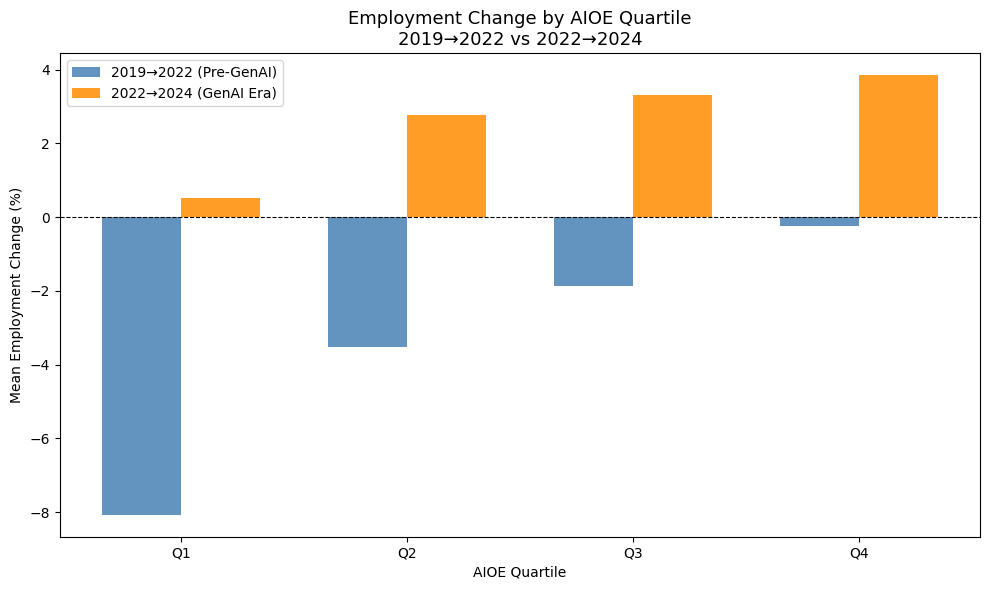


Mean employment change by quartile and interval:
               emp_change_pct_19_22  emp_change_pct_22_24
AIOE_quartile                                            
Q1                            -8.07                  0.51
Q2                            -3.52                  2.78
Q3                            -1.86                  3.31
Q4                            -0.23                  3.85


In [21]:
# ── Two-interval employment change comparison by quartile ────────
intervals = df_q.groupby('AIOE_quartile')[
       ['emp_change_pct_19_22', 'emp_change_pct_22_24']
].mean()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(intervals))
width = 0.35

ax.bar(x - width/2, intervals['emp_change_pct_19_22'],
       width, label='2019→2022 (Pre-GenAI)',
       color='steelblue', alpha=0.85)
ax.bar(x + width/2, intervals['emp_change_pct_22_24'],
       width, label='2022→2024 (GenAI Era)',
       color='darkorange', alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Employment Change by AIOE Quartile\n'
             '2019→2022 vs 2022→2024', fontsize=13)
ax.set_xlabel('AIOE Quartile')
ax.set_ylabel('Mean Employment Change (%)')
ax.set_xticks(x)
ax.set_xticklabels(intervals.index)
ax.legend()
plt.tight_layout()
plt.show()

print("\nMean employment change by quartile and interval:")
print(intervals.round(2).to_string())

In [ ]:
# Wage correlation with p-value
r_wage, p_wage = scipy_stats.pearsonr(
    data['AIOE'], data['real_median_wage_2024']
)

valid = data.dropna(subset=['emp_change_pct_19_24'])
r_emp, p_emp = scipy_stats.pearsonr(
    valid['AIOE'], valid['emp_change_pct_19_24']
)

print("── Key Correlation Results ─────────────────────────")
print(f"AIOE vs Median Wage 2024:          r={r_wage:.3f}, p={p_wage:.4f}")
print(f"AIOE vs Employment Change 19-24:   r={r_emp:.3f},  p={p_emp:.4f}")
print()
print("Interpretation:")
print(f"  Wage correlation:       {'significant' if p_wage < 0.05 else 'not significant'} at p<0.05")
print(f"  Employment correlation: {'significant' if p_emp < 0.05 else 'not significant'} at p<0.05")

── Key Correlation Results ─────────────────────────
AIOE vs Median Wage 2024:          r=0.509, p=0.0000
AIOE vs Employment Change 19-24:   r=0.192,  p=0.0000

Interpretation:
  Wage correlation:       significant at p<0.05
  Employment correlation: significant at p<0.05
